<a href="https://colab.research.google.com/github/biswal-prem-5677/Coding-Journey/blob/main/ai/02_machine_learning/ml_projects/spam_classifier/experiment_sms_spam_classification_tfidf_naive_bayes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Spam Message Classifier: NLP and Scikit-learn

This notebook demonstrates how to build a spam message classifier using Python, Natural Language Processing (NLP) techniques, and machine learning models from the Scikit-learn library. We will cover dataset loading, exploratory data analysis, text preprocessing, model training, and evaluation.

In [8]:
import pandas as pd
import urllib.request
import os

# Define the URL for the dataset
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00228/smsspamcollection.zip'
zip_file_name = 'smsspamcollection.zip'

# Download the dataset if it doesn't exist
if not os.path.exists(zip_file_name):
    print(f"Downloading {zip_file_name}...")
    urllib.request.urlretrieve(url, zip_file_name)
    print("Download complete.")
else:
    print(f"{zip_file_name} already exists. Skipping download.")

# Extract the dataset (it contains a single .tsv file)
import zipfile
with zipfile.ZipFile(zip_file_name, 'r') as zip_ref:
    zip_ref.extractall('.')

# Load the dataset into a pandas DataFrame
df = pd.read_csv('SMSSpamCollection', sep='\t', header=None, names=['label', 'message'])

print("First 5 rows of the dataset:")
display(df.head())

print(f"\nDataset shape: {df.shape}")
print("Dataset information:")
display(df.info())

smsspamcollection.zip already exists. Skipping download.
First 5 rows of the dataset:


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."



Dataset shape: (5572, 2)
Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


None

## 1. Dataset Loading and Initial Exploration

We download the UCI SMS Spam Collection dataset and load it into a pandas DataFrame, then perform a quick check of its structure.

## 2. Exploratory Data Analysis (EDA)

In this section, we'll explore the dataset to understand its characteristics, such as the distribution of 'ham' vs. 'spam' messages and the length of the messages.

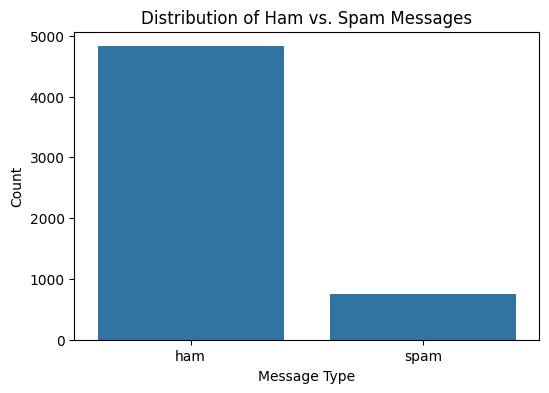


Value counts for 'label' column:


,count
label,
ham,4825
spam,747


Percentage of Spam messages: 13.41%


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Distribution of 'ham' vs 'spam' labels
plt.figure(figsize=(6, 4))
sns.countplot(x='label', data=df)
plt.title('Distribution of Ham vs. Spam Messages')
plt.xlabel('Message Type')
plt.ylabel('Count')
plt.show()

print("\nValue counts for 'label' column:")
display(df['label'].value_counts())
print(f"Percentage of Spam messages: {df['label'].value_counts(normalize=True)['spam'] * 100:.2f}%")

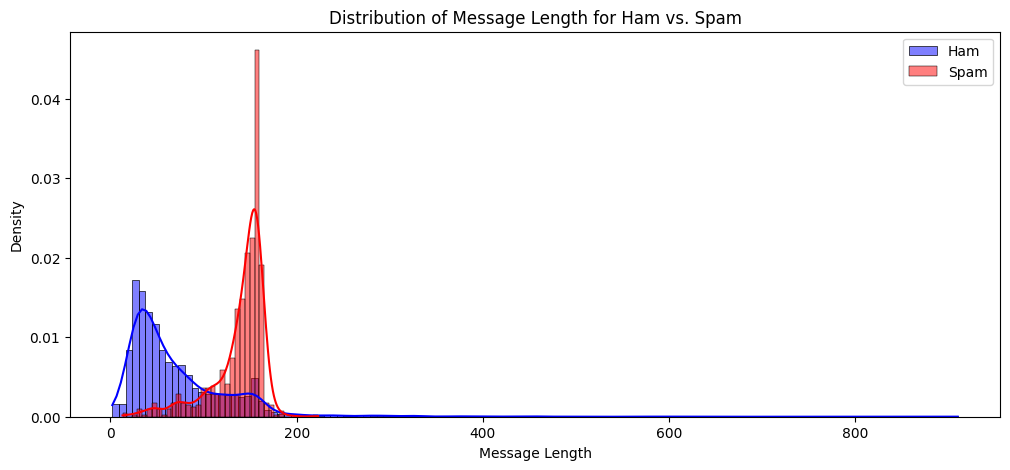


Descriptive statistics for message length by label:


,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
ham,4825.0,71.482487,58.440652,2.0,33.0,52.0,93.0,910.0
spam,747.0,138.670683,28.873603,13.0,133.0,149.0,157.0,223.0


In [10]:
# Add a new column for message length
df['message_length'] = df['message'].apply(len)

# Visualize message length distribution for ham and spam
plt.figure(figsize=(12, 5))
sns.histplot(df[df['label'] == 'ham']['message_length'], color='blue', label='Ham', kde=True, stat='density', alpha=0.5)
sns.histplot(df[df['label'] == 'spam']['message_length'], color='red', label='Spam', kde=True, stat='density', alpha=0.5)
plt.title('Distribution of Message Length for Ham vs. Spam')
plt.xlabel('Message Length')
plt.ylabel('Density')
plt.legend()
plt.show()

print("\nDescriptive statistics for message length by label:")
display(df.groupby('label')['message_length'].describe())

## 3. Data Preprocessing: Label Encoding

To prepare the data for machine learning, we need to convert the categorical 'label' column ('ham', 'spam') into numerical values (0, 1).

In [11]:
# Convert 'label' column to numerical (0 for ham, 1 for spam)
df['label'] = df['label'].map({'ham': 0, 'spam': 1})

print("First 5 rows with numerical labels:")
display(df.head())

print("\nValue counts for 'label' column after encoding:")
display(df['label'].value_counts())

First 5 rows with numerical labels:


,label,message,message_length
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61



Value counts for 'label' column after encoding:


,count
label,
0,4825
1,747


## 4. Text Preprocessing: TF-IDF Vectorization

We convert the text messages into numerical features using TF-IDF (Term Frequency-Inverse Document Frequency), which is crucial for machine learning models to process text data. TF-IDF assigns weights to words based on their frequency in a document and rarity across all documents.

In [12]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize the TF-IDF Vectorizer. We'll limit to 5000 features and remove common English stop words.
tfidf_vectorizer = TfidfVectorizer(max_features=5000, stop_words='english')

# Fit the vectorizer to the 'message' column and transform the messages into a feature matrix
X = tfidf_vectorizer.fit_transform(df['message'])

# Assign the encoded 'label' to the target variable y
y = df['label']

print(f"Shape of TF-IDF feature matrix (X): {X.shape}")
print(f"Shape of target vector (y): {y.shape}")

Shape of TF-IDF feature matrix (X): (5572, 5000)
Shape of target vector (y): (5572,)


## 5. Data Splitting

Before training any machine learning model, it's crucial to split the dataset into training and testing sets. This helps in evaluating the model's performance on unseen data and prevents overfitting. We'll use 80% of the data for training and 20% for testing.

In [13]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
# test_size=0.2 means 20% of the data will be used for testing
# random_state ensures reproducibility of the split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (4457, 5000)
Shape of X_test: (1115, 5000)
Shape of y_train: (4457,)
Shape of y_test: (1115,)


## 6. Model Training and Evaluation

We'll train a Multinomial Naive Bayes classifier, which is well-suited for text classification with discrete features (like TF-IDF scores). After training, we'll evaluate its performance using common classification metrics like accuracy, precision, recall, and F1-score.

Training the Multinomial Naive Bayes model...
Model training complete.

--- Model Evaluation ---
Accuracy: 0.9839
Precision: 1.0000
Recall: 0.8792
F1-Score: 0.9357

Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       966
           1       1.00      0.88      0.94       149

    accuracy                           0.98      1115
   macro avg       0.99      0.94      0.96      1115
weighted avg       0.98      0.98      0.98      1115



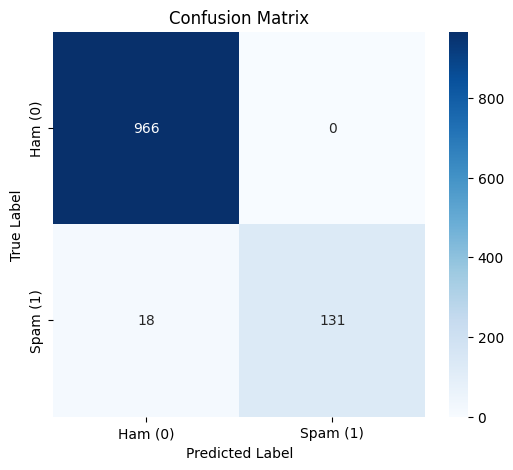

In [14]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

# Initialize the Multinomial Naive Bayes model
model = MultinomialNB()

print("Training the Multinomial Naive Bayes model...")
model.fit(X_train, y_train)
print("Model training complete.")

# Make predictions on the test set
y_pred = model.predict(X_test)

print("\n--- Model Evaluation ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall: {recall_score(y_test, y_pred):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Display Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Ham (0)', 'Spam (1)'], yticklabels=['Ham (0)', 'Spam (1)'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

## 7. Making Predictions on New Messages

Finally, we can use our trained model to classify new, unseen messages as 'ham' or 'spam'. It's important to preprocess new messages (vectorize them) in the same way as the training data before making predictions.

In [15]:
def predict_message_type(message):
    # Vectorize the new message using the trained TF-IDF vectorizer
    message_transformed = tfidf_vectorizer.transform([message])

    # Make prediction
    prediction = model.predict(message_transformed)

    # Return 'spam' or 'ham'
    if prediction[0] == 1:
        return 'spam'
    else:
        return 'ham'

# Test with some example messages
example_message_1 = "Congratulations! You've won a free iPhone. Claim now!"
example_message_2 = "Hey, what are you doing this weekend? Wanna grab coffee?"
example_message_3 = "WINNER!! As a valued customer you have been selected to receive a \"£900 prize reward\". To claim call 09061701461. Claim code KL341. Valid 12 hours only."
example_message_4 = "Hi, just checking in to see if you received my last email."
example_message_5 = "Your account has been credited with $1,000,000. Click here to claim."

print(f"Message 1: '{example_message_1}' is -> {predict_message_type(example_message_1)}")
print(f"Message 2: '{example_message_2}' is -> {predict_message_type(example_message_2)}")
print(f"Message 3: '{example_message_3}' is -> {predict_message_type(example_message_3)}")
print(f"Message 4: '{example_message_4}' is -> {predict_message_type(example_message_4)}")
print(f"Message 5: '{example_message_5}' is -> {predict_message_type(example_message_5)}")

# You can also try your own message:
# my_message = "Enter your message here"
# print(f"Your message: '{my_message}' is -> {predict_message_type(my_message)}")

Message 1: 'Congratulations! You've won a free iPhone. Claim now!' is -> spam
Message 2: 'Hey, what are you doing this weekend? Wanna grab coffee?' is -> ham
Message 3: 'WINNER!! As a valued customer you have been selected to receive a "£900 prize reward". To claim call 09061701461. Claim code KL341. Valid 12 hours only.' is -> spam
Message 4: 'Hi, just checking in to see if you received my last email.' is -> ham
Message 5: 'Your account has been credited with $1,000,000. Click here to claim.' is -> spam


## Conclusion

This notebook successfully demonstrates the process of building a spam message classifier using a Multinomial Naive Bayes model with TF-IDF vectorization. The model achieved high performance metrics, indicating its effectiveness in distinguishing between ham and spam messages.